Numery CAS z brakującymi danymi:
  12027-96-2
  12036-37-2
  1309-42-8
  1309-64-4
  21645-51-2
  225789-38-8


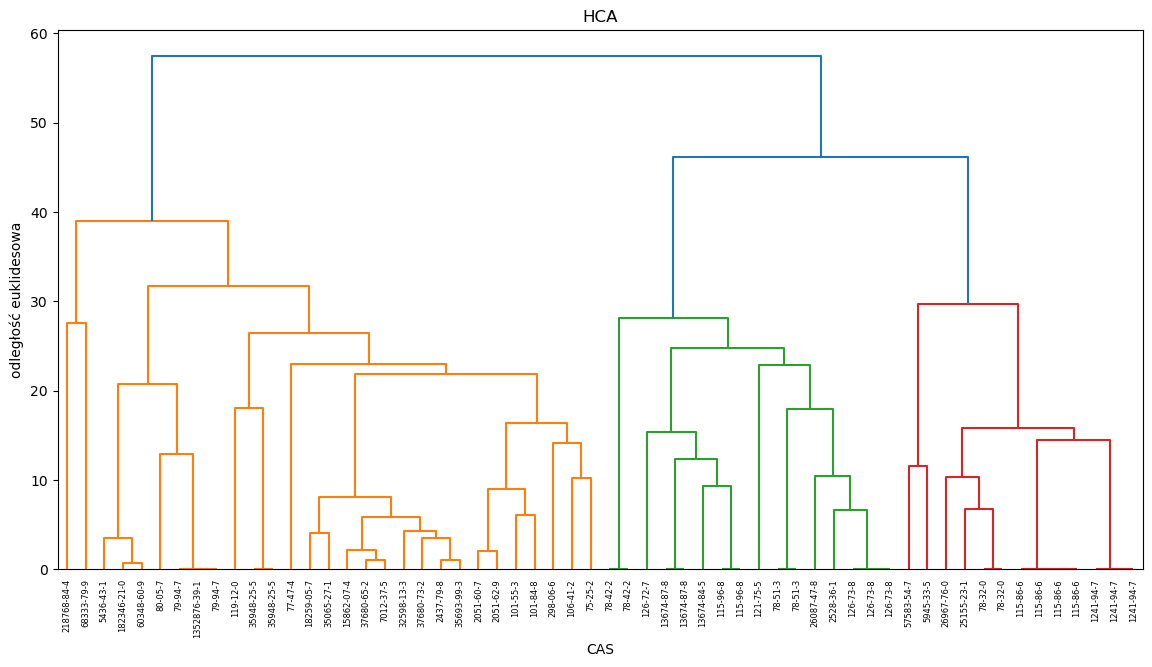

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

df = pd.read_excel('deskryptory_z_cas.xlsx', dtype={0: str})

cas = df.iloc[:, 0].values
dane = df.iloc[:, 1:].values
dane_df = df.iloc[:, 1:]

kompletne_wiersze = dane_df.notna().all(axis=1)
niekompletne_cas = cas[~kompletne_wiersze]
print(f"Numery CAS z brakującymi danymi:")
for c in niekompletne_cas:
    print(f"  {c}")

cas_kompletne = cas[kompletne_wiersze]
dane_kompletne = dane[kompletne_wiersze]

scaler = StandardScaler()
dane_znormalizowane = scaler.fit_transform(dane_kompletne)

dane_znormalizowane = np.array(dane_znormalizowane, dtype=float)

odleglosci = pdist(dane_znormalizowane, metric='euclidean')
z = linkage(odleglosci, method='ward')
    
plt.figure(figsize=(14, 7))
dendrogram(z, labels=cas_kompletne, leaf_rotation=90)
plt.title('HCA')
plt.xlabel('CAS')
plt.ylabel('odległość euklidesowa')
plt.show()